In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv(r"C:\Users\admin\Desktop\CSV File\Finance_customers.csv")
transactions = pd.read_csv(r"C:\Users\admin\Desktop\CSV File\finance_transactions.csv")

In [3]:
df = pd.merge(
    transactions,
    customers,
    on="customer_id",
    how="left"
)

In [4]:
df.head()

,transaction_id,transaction_date,account_id,customer_id,transaction_type,channel,merchant_category,amount,fee_amount,tax_amount,...,fisrt_name,second_name,gender,date_of_birth,city,state,occupation,customer_segment,annual_income,join_date
0,T00000001,21-02-2025,A001795,C00629,Investment,Mobile App,Food Delivery,24721.24,123.61,22.25,...,Neha,Desai,Female,16-07-1994,Coimbatore,Tamil Nadu,Salaried,Premium,1521243.86,28-03-2025
1,T00000002,28-01-2023,A004859,C02038,Transfer,UPI,Groceries,18711.77,93.56,16.84,...,Aarav,Chopra,Female,18-12-1989,Bengaluru,Karnataka,Freelancer,Retail,365023.04,15-01-2021
2,T00000003,25-06-2024,A003081,C00652,Transfer,Net Banking,Groceries,45865.90,0.00,0.00,...,Sneha,Verma,Male,24-06-1988,Chandigarh,Chandigarh,Retired,Wealth,1973706.42,02-10-2024
3,T00000004,20-02-2025,A004122,C01357,Withdrawal,Auto Debit,Salary,4310.91,NaN,0.78,...,Pooja,Reddy,Male,24-09-2002,Pune,Maharashtra,Self Employed,Corporate,555476.53,15-03-2020
4,T00000005,06-08-2024,A004150,C02547,Deposit,Branch,Shopping,11646.45,0.00,0.00,...,Reyansh,Chopra,Female,22-09-2004,Mysuru,Karnataka,Self Employed,SME,1107795.82,25-09-2023


In [10]:
df.drop_duplicates('transaction_id', inplace=True)

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.dropna(inplace=True)

In [13]:
df.drop_duplicates(inplace=True)

In [22]:
df.columns

Index(['transaction_id', 'transaction_date', 'account_id', 'customer_id',
       'transaction_type', 'channel', 'merchant_category', 'amount',
       'fee_amount', 'tax_amount', 'currency', 'transaction_status',
       'is_fraud', 'risk_score', 'reference_no', 'fisrt_name', 'second_name',
       'gender', 'date_of_birth', 'city', 'state', 'occupation',
       'customer_segment', 'annual_income', 'join_date', 'Month',
       'Month_name'],
      dtype='object')

In [11]:
total_customers = df['customer_id'].nunique()

total_transactions = len(df)

total_amount = df['amount'].sum()

avg_transaction = df['amount'].mean()

total_fee = df['fee_amount'].sum()

total_tax = df['tax_amount'].sum()

In [12]:
print("Total Customers:",total_customers)
print("Total transactions:",total_transactions)
print("Total Revenue:",total_amount)
print("Avg tansactions:",avg_transaction)
print("Total Fees:",total_fee)
print("Total Tax:",total_tax)


Total Customers: 3983
Total transactions: 50000
Total Revenue: 455391141.16
Avg tansactions: 9107.8228232
Total Fees: 725893.7200000001
Total Tax: 130736.35000000002


In [33]:
#Count of fraud

df['is_fraud'].value_counts()

is_fraud
0.0    49437
Name: count, dtype: int64

In [17]:
df['is_fraud'] = df['is_fraud'].map({'yes':1, 'No':0})

In [18]:
fraud_rate = (
    df['is_fraud'].sum()
    /
    len(df)
)*100

print("Fraud Rate:",fraud_rate)

Fraud Rate: 0.0


C:\Users\admin\AppData\Local\Temp\ipykernel_14968\297052652.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['transaction_date'] = pd.to_datetime(


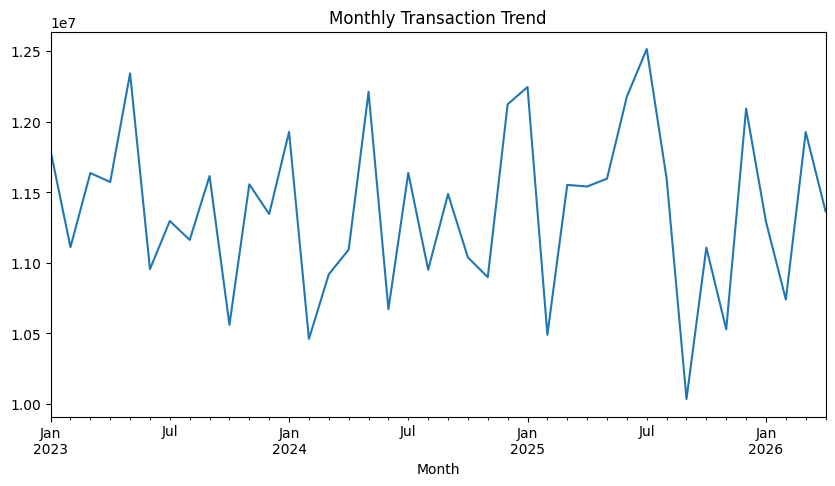

In [19]:
df['transaction_date'] = pd.to_datetime(
    df['transaction_date']
)

df['Month'] = df['transaction_date'].dt.to_period('M')

monthly_sales = df.groupby(
    'Month'
)['amount'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title('Monthly Transaction Trend')
plt.show()

In [29]:
df['Month_name'] = df['transaction_date'].dt.month_name()

In [26]:
df.columns

Index(['transaction_id', 'transaction_date', 'account_id', 'customer_id',
       'transaction_type', 'channel', 'merchant_category', 'amount',
       'fee_amount', 'tax_amount', 'currency', 'transaction_status',
       'is_fraud', 'risk_score', 'reference_no', 'fisrt_name', 'second_name',
       'gender', 'date_of_birth', 'city', 'state', 'occupation',
       'customer_segment', 'annual_income', 'join_date', 'Month',
       'Month_name'],
      dtype='object')

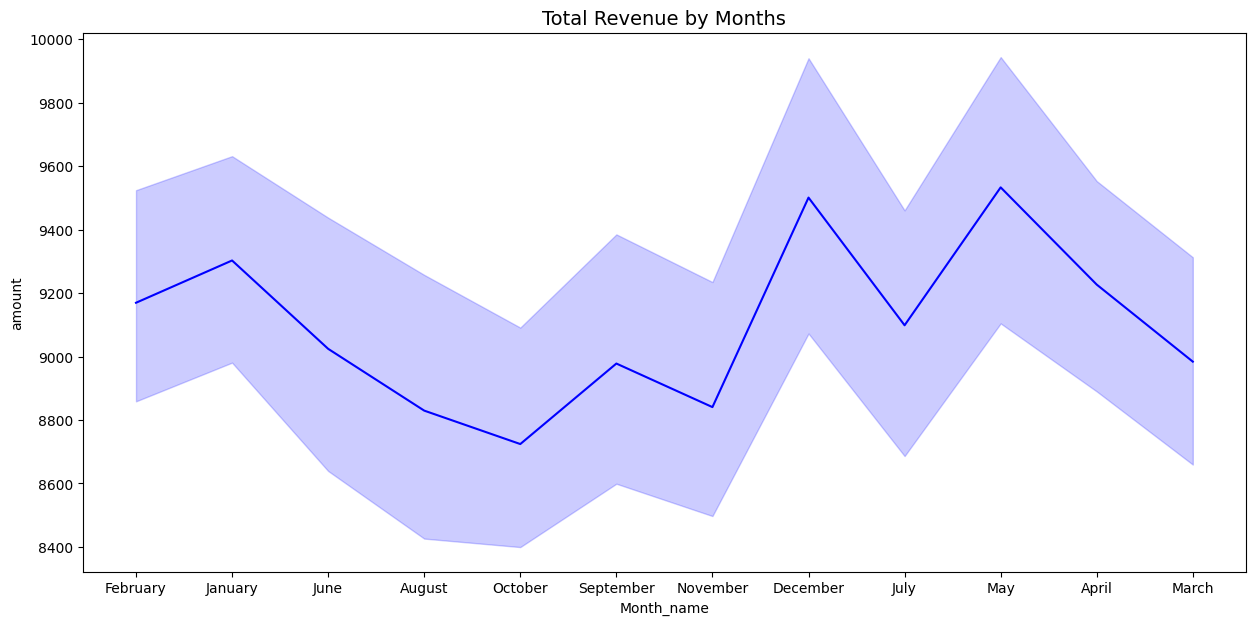

In [36]:
plt.figure(figsize=(15,7))

monthly_revenue = df.groupby('Month_name')[['amount']].sum().sort_values(by='amount')

sns.lineplot(x='Month_name', y='amount', data=df, color='Blue')
plt.title("Total Revenue by Months", fontsize=14)
plt.show()



In [12]:
top_customers = (
df.groupby('customer_id')['amount']
.sum()
.sort_values(ascending=False)
.head(10)
)

print(top_customers)

customer_id
C03734    607366.67
C03896    595663.43
C00069    587842.41
C04524    545285.54
C04201    518306.99
C04671    514772.27
C01375    497686.87
C02133    495012.28
C02313    472525.31
C04059    470414.75
Name: amount, dtype: float64


In [13]:
fraud = df[df['is_fraud']==1]

fraud.groupby(
'merchant_category'
)['transaction_id'].count()\
.sort_values(ascending=False)

Series([], Name: transaction_id, dtype: int64)

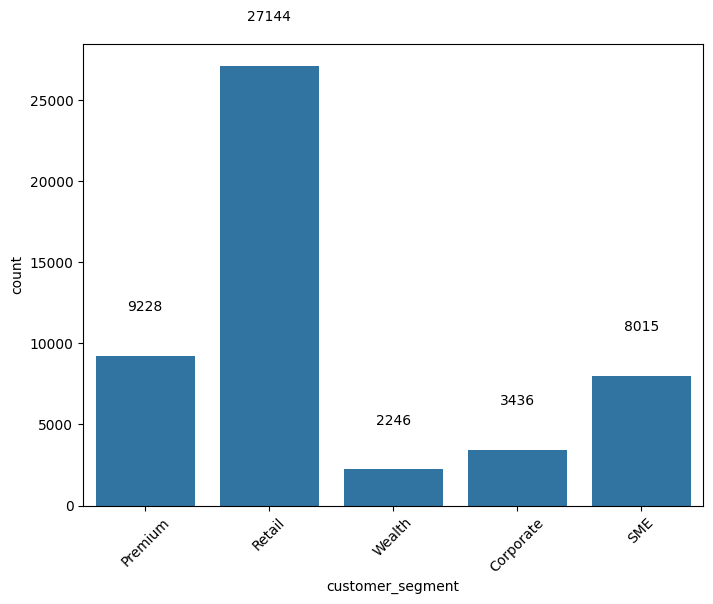

In [20]:
plt.figure(figsize=(8,6))


ax=sns.countplot(
    data=df,
    x='customer_segment'
)
ax.bar_label(ax.containers[0],padding=30)
plt.xticks(rotation=45)
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [25]:
y = df['is_fraud']

X = df[['amount','fee_amount',
        'tax_amount','risk_score']]

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

cleaned_data =pd.concat([X,y], axis=1).dropna()
X_clean = cleaned_data[['amount','fee_amount','tax_amount','risk_score']]
y_clean = cleaned_data['is_fraud']

X_train,X_test,y_train,y_test = train_test_split(
X_clean,y_clean,test_size=0.2,random_state=42
)

model = RandomForestClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print(classification_report(
y_test,pred
))



C:\Users\admin\AppData\Local\Temp\ipykernel_10332\3810212391.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = pd.to_numeric(X[col], errors='coerce')


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9883

    accuracy                           1.00      9883
   macro avg       1.00      1.00      1.00      9883
weighted avg       1.00      1.00      1.00      9883

